<a href="https://colab.research.google.com/github/abimouloud/TokenMobileViT/blob/main/Mobilevit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mobile-ViT

**Last modified:** 2026/08/022 by: ABIMOULOUD mouhamed laid<br>
Cite this article: TokenMobileViT: A Lightweight Hybrid Vision
Transformer with Learnable Token Compression
for Lung and Colon Classification

In [ ]:
!pip install --upgrade pip
!pip install --upgrade tensorflow
!pip install --upgrade mediapipe-model-maker
!pip install -U tensorflow-addons
!pip install git+https://github.com/tensorflow/addons.git


In [ ]:
import tensorflow_addons as tfa
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Model
import tensorflow_addons as tfa
from keras.applications import imagenet_utils
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import numpy as np
import tensorflow as tf
from tensorflow import keras
import tensorflow_addons as tfa
from keras.applications import imagenet_utils
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import json
import math
import os
import cv2
from PIL import Image
from keras.callbacks import Callback, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
from keras.utils import to_categorical
from keras.models import Sequential
from keras.optimizers import Adam
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import cohen_kappa_score, accuracy_score
import scipy
from tqdm import tqdm
from keras import backend as K
import gc
from functools import partial
from sklearn import metrics
from collections import Counter
import itertools
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score

tfds.disable_progress_bar()

/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.13.0 and strictly below 2.16.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.20.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're u

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Hyperparameters

In [ ]:
# Values are from table 4.
patch_size = 16  # 2x2, for the Transformer blocks.
image_size = 256
expansion_factor = 8  # expansion factor for the MobileNetV2 blocks.

In [ ]:
#Transfer 'jpg' images to an array IMG
def Dataset_loader(DIR, RESIZE, sigmaX=10):
    IMG = []
    read = lambda imname: np.asarray(Image.open(imname).convert("RGB"))
    for IMAGE_NAME in tqdm(os.listdir(DIR)):
        PATH = os.path.join(DIR,IMAGE_NAME)
        _, ftype = os.path.splitext(PATH)
        if ftype == ".jpeg":
            img = read(PATH)

            img = cv2.resize(img, (RESIZE,RESIZE))

            IMG.append(np.array(img))
    return IMG



# Load the train datasets for three classes: benign, malignant, normal
benign_train = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/train/lung_adenocarcinoma', 256))
malign_train = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/train/lung_benign_tissue', 256))
normal_train = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/train/lung_lung squamous', 256))

# Load the test datasets for three classes: benign, malignant, normal
benign_test = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/test/lung_adenocarcinoma', 256))
malign_test = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/test/lung_benign_tissue', 256))
normal_test = np.array(Dataset_loader('/content/drive/MyDrive/lung_image_splited/test/lung_lung squamous', 256))

100%|██████████| 1000/1000 [00:25<00:00, 39.87it/s]


In [ ]:
# Skin Cancer: Malignant vs. Benign
# Create labels
benign_train_label = np.zeros(len(benign_train))
malign_train_label = np.ones(len(malign_train))
normal_train_label = np.full(len(normal_train), 2)
benign_test_label = np.zeros(len(benign_test))
malign_test_label = np.ones(len(malign_test))
normal_test_label = np.full(len(normal_test), 2)


# Merge data
X_train = np.concatenate((benign_train, malign_train,normal_train), axis = 0)
Y_train = np.concatenate((benign_train_label, malign_train_label,normal_train_label), axis = 0)
X_test = np.concatenate((benign_test, malign_test,normal_test), axis = 0)
Y_test = np.concatenate((benign_test_label, malign_test_label,normal_test_label), axis = 0)

# Shuffle train data
s = np.arange(X_train.shape[0])
np.random.shuffle(s)
X_train = X_train[s]
Y_train = Y_train[s]

# Shuffle test data
s = np.arange(X_test.shape[0])
np.random.shuffle(s)
X_test = X_test[s]
Y_test = Y_test[s]

# To categorical
Y_train = to_categorical(Y_train, num_classes= 3)
Y_test = to_categorical(Y_test, num_classes= 3)

In [ ]:
x_train, x_val, y_train, y_val = train_test_split(
    X_train, Y_train,
    test_size=0.2,
    random_state=11
)

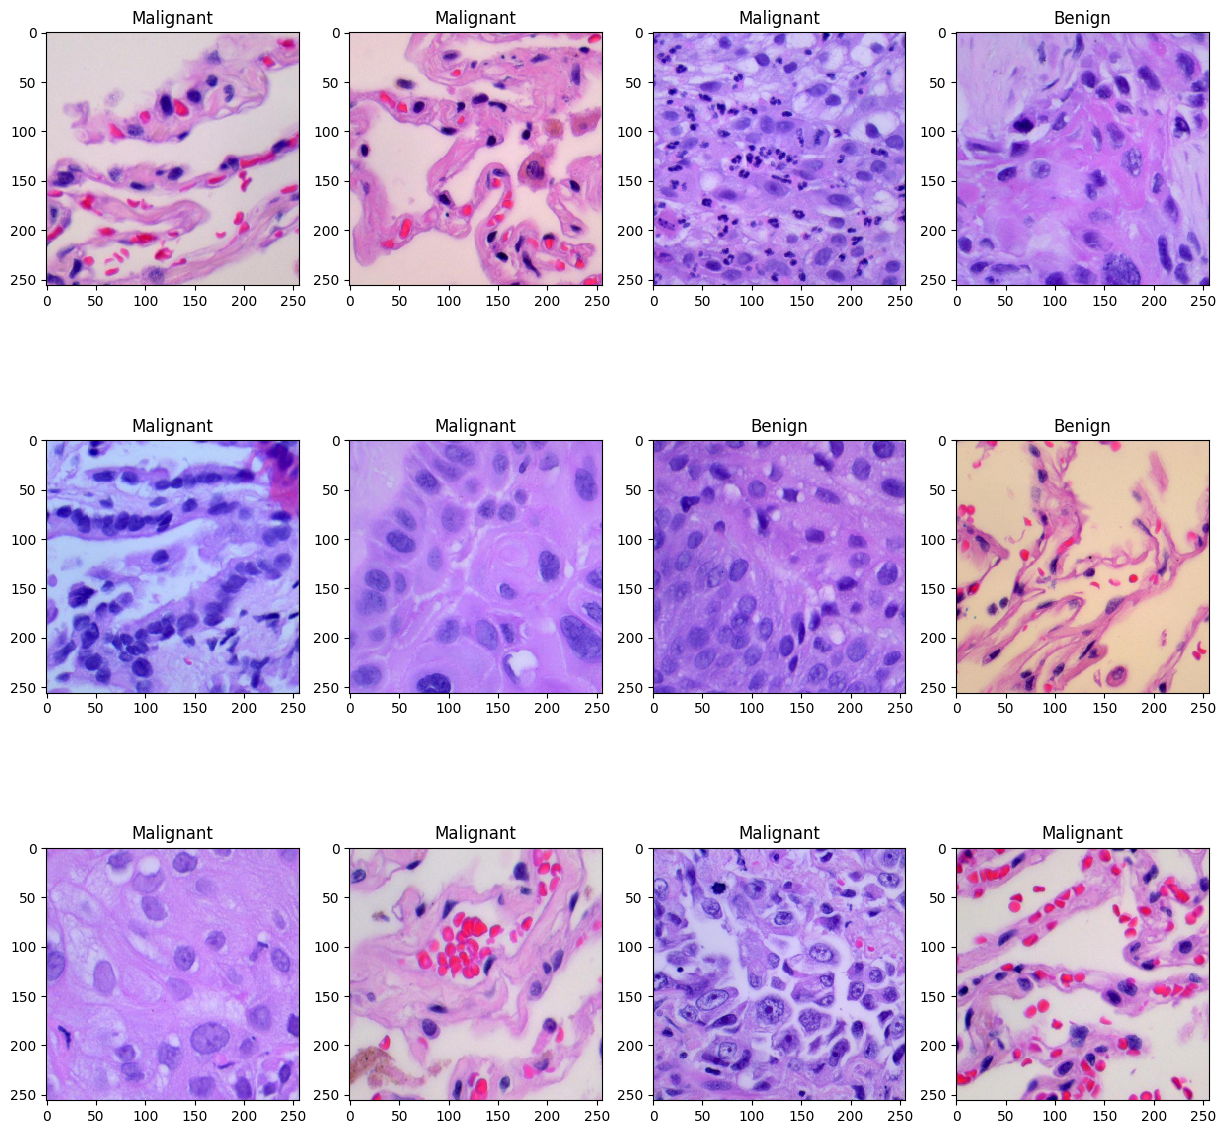

In [ ]:
# # Display first 15 images of moles, and how they are classified
w=60
h=40
fig=plt.figure(figsize=(15, 15))
columns = 4
rows = 3

for i in range(1, columns*rows +1):
    ax = fig.add_subplot(rows, columns, i)
    if np.argmax(Y_train[i]) == 0:
        ax.title.set_text('Benign')
    else:
        ax.title.set_text('Malignant')
    plt.imshow(x_train[i], interpolation='nearest')
plt.show()

In [ ]:
BATCH_SIZE = 64

# Using original generator
train_generator = ImageDataGenerator(

    )

In [ ]:
learning_rate = 0.002
label_smoothing_factor = 0.1
batch_size = 16
epochs = 20
input_shape = (256, 256, 3)
num_classes = 3


## MobileViT utilities

The MobileViT architecture is comprised of the following blocks:

* Strided 3x3 convolutions that process the input image.
* [MobileNetV2](https://arxiv.org/abs/1801.04381)-style inverted residual blocks for
downsampling the resolution of the intermediate feature maps.
* MobileViT blocks that combine the benefits of Transformers and convolutions. It is
presented in the figure below (taken from the
[original paper](https://arxiv.org/abs/2110.02178)):


![](https://i.imgur.com/mANnhI7.png)

In [ ]:

def conv_block(x, filters=16, kernel_size=3, strides=2):
    conv_layer = layers.Conv2D(
        filters,
        kernel_size,
        strides=strides,
        activation=keras.activations.swish,
        padding="same",
    )
    return conv_layer(x)


# Reference: https://github.com/keras-team/keras/blob/e3858739d178fe16a0c77ce7fab88b0be6dbbdc7/keras/applications/imagenet_utils.py#L413C17-L435


def correct_pad(inputs, kernel_size):
    img_dim = 2 if backend.image_data_format() == "channels_first" else 1
    input_size = inputs.shape[img_dim : (img_dim + 2)]
    if isinstance(kernel_size, int):
        kernel_size = (kernel_size, kernel_size)
    if input_size[0] is None:
        adjust = (1, 1)
    else:
        adjust = (1 - input_size[0] % 2, 1 - input_size[1] % 2)
    correct = (kernel_size[0] // 2, kernel_size[1] // 2)
    return (
        (correct[0] - adjust[0], correct[0]),
        (correct[1] - adjust[1], correct[1]),
    )


# Reference: https://git.io/JKgtC


def inverted_residual_block(x, expanded_channels, output_channels, strides=1):
    m = layers.Conv2D(expanded_channels, 1, padding="same", use_bias=False)(x)
    m = layers.BatchNormalization()(m)
    m = keras.activations.swish(m)

    if strides == 2:
        m = layers.ZeroPadding2D(padding=correct_pad(m, 3))(m)
    m = layers.DepthwiseConv2D(
        3, strides=strides, padding="same" if strides == 1 else "valid", use_bias=False
    )(m)
    m = layers.BatchNormalization()(m)
    m = keras.activations.swish(m)

    m = layers.Conv2D(output_channels, 1, padding="same", use_bias=False)(m)
    m = layers.BatchNormalization()(m)

    if keras.ops.equal(x.shape[-1], output_channels) and strides == 1:
        return layers.Add()([m, x])
    return m


# Reference:
# https://keras.io/examples/vision/image_classification_with_vision_transformer/


def mlp(x, hidden_units, dropout_rate):
    for units in hidden_units:
        x = layers.Dense(units, activation=keras.activations.swish)(x)
        x = layers.Dropout(dropout_rate)(x)
    return x


def transformer_block(x, transformer_layers, projection_dim, num_heads=2):
    for _ in range(transformer_layers):
        # Layer normalization 1.
        x1 = layers.LayerNormalization(epsilon=1e-6)(x)
        # Create a multi-head attention layer.
        attention_output = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=projection_dim, dropout=0.1
        )(x1, x1)
        # Skip connection 1.
        x2 = layers.Add()([attention_output, x])
        # Layer normalization 2.
        x3 = layers.LayerNormalization(epsilon=1e-6)(x2)
        # MLP.
        x3 = mlp(
            x3,
            hidden_units=[x.shape[-1] * 2, x.shape[-1]],
            dropout_rate=0.1,
        )
        # Skip connection 2.
        x = layers.Add()([x3, x2])

    return x


def mobilevit_block(x, num_blocks, projection_dim, strides=1):
    # Local projection with convolutions.
    local_features = conv_block(x, filters=projection_dim, strides=strides)
    local_features = conv_block(
        local_features, filters=projection_dim, kernel_size=1, strides=strides
    )

    # Unfold into patches and then pass through Transformers.
    num_patches = int((local_features.shape[1] * local_features.shape[2]) / patch_size)
    non_overlapping_patches = layers.Reshape((patch_size, num_patches, projection_dim))(
        local_features
    )
    global_features = transformer_block(
        non_overlapping_patches, num_blocks, projection_dim
    )

    # Fold into conv-like feature-maps.
    folded_feature_map = layers.Reshape((*local_features.shape[1:-1], projection_dim))(
        global_features
    )

    # Apply point-wise conv -> concatenate with the input features.
    folded_feature_map = conv_block(
        folded_feature_map, filters=x.shape[-1], kernel_size=1, strides=strides
    )
    local_global_features = layers.Concatenate(axis=-1)([x, folded_feature_map])

    # Fuse the local and global features using a convoluion layer.
    local_global_features = conv_block(
        local_global_features, filters=projection_dim, strides=strides
    )

    return local_global_features


**More on the MobileViT block**:

* First, the feature representations (A) go through convolution blocks that capture local
relationships. The expected shape of a single entry here would be `(h, w, num_channels)`.
* Then they get unfolded into another vector with shape `(p, n, num_channels)`,
where `p` is the area of a small patch, and `n` is `(h * w) / p`. So, we end up with `n`
non-overlapping patches.
* This unfolded vector is then passed through a Tranformer block that captures global
relationships between the patches.
* The output vector (B) is again folded into a vector of shape `(h, w, num_channels)`
resembling a feature map coming out of convolutions.

Vectors A and B are then passed through two more convolutional layers to fuse the local
and global representations. Notice how the spatial resolution of the final vector remains
unchanged at this point. The authors also present an explanation of how the MobileViT
block resembles a convolution block of a CNN. For more details, please refer to the
original paper.

In [ ]:
import os
import tensorflow as tf

os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers
from keras import backend

import tensorflow_datasets as tfds

tfds.disable_progress_bar()

Next, we combine these blocks together and implement the MobileViT architecture (XXS
variant). The following figure (taken from the original paper) presents a schematic
representation of the architecture:

![](https://i.ibb.co/sRbVRBN/image.png)

In [ ]:

def create_mobilevit(num_classes=5):
    inputs = keras.Input((image_size, image_size, 3))
    x = layers.Rescaling(scale=1.0 / 255)(inputs)

    # Initial conv-stem -> MV2 block.
    x = conv_block(x, filters=16)
    x = inverted_residual_block(
        x, expanded_channels=16 * expansion_factor, output_channels=16
    )

    # Downsampling with MV2 block.
    x = inverted_residual_block(
        x, expanded_channels=16 * expansion_factor, output_channels=24, strides=2
    )
    x = inverted_residual_block(
        x, expanded_channels=24 * expansion_factor, output_channels=24
    )
    x = inverted_residual_block(
        x, expanded_channels=24 * expansion_factor, output_channels=24
    )

    # First MV2 -> MobileViT block.
    x = inverted_residual_block(
        x, expanded_channels=24 * expansion_factor, output_channels=48, strides=2
    )
    x = mobilevit_block(x, num_blocks=2, projection_dim=64)

    # Second MV2 -> MobileViT block.
    x = inverted_residual_block(
        x, expanded_channels=64 * expansion_factor, output_channels=64, strides=2
    )
    x = mobilevit_block(x, num_blocks=4, projection_dim=80)

    # Third MV2 -> MobileViT block.
    x = inverted_residual_block(
        x, expanded_channels=80 * expansion_factor, output_channels=80, strides=2
    )
    x = mobilevit_block(x, num_blocks=3, projection_dim=96)
    x = conv_block(x, filters=320, kernel_size=1, strides=1)

    # Classification head.
    x = layers.GlobalAvgPool2D()(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs)


mobilevit_xxs = create_mobilevit()
mobilevit_xxs.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_2         │ (None, 256, 256,  │          0 │ input_layer_2[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 128, 128,  │        448 │ rescaling_2[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 128, 128,  │      2,048 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_7[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_3 (Silu)       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_1  │ (None, 128, 128,  │      1,152 │ silu_3[0][0]      │
│ (DepthwiseConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ depthwise_conv2d… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_4 (Silu)       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 128, 128,  │      2,048 │ silu_4[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │         64 │ conv2d_8[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 16)               │            │ conv2d_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 128, 128,  │      2,048 │ add_1[0][0]       │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_9[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ silu_5 (Silu)       │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 129, 129,  │          0 │ silu_5[0][0]      │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ depthwise_conv2d_2  │ (None, 64, 64,    │      1,152 │ zero_padding2d[0

 Total params: 1,489,973 (5.68 MB)

 Trainable params: 1,481,477 (5.65 MB)

 Non-trainable params: 8,496 (33.19 KB)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, f1_score
from tensorflow import keras
import time

optimizer = 'adam'
loss_fn = keras.losses.CategoricalCrossentropy(from_logits=False, name="categorical_crossentropy")

def run_experiment(epochs):
    mobilevit_xxs = create_mobilevit(num_classes=num_classes)
    mobilevit_xxs.compile(optimizer=optimizer, loss=loss_fn, metrics=["accuracy"])

    checkpoint_filepath = "/content/drive/MyDrive/saved_models/a.h5"
    checkpoint_callback = keras.callbacks.ModelCheckpoint(
        checkpoint_filepath,
        monitor="val_accuracy",
        save_best_only=False,
        save_weights_only=False,
    )

    start_time = time.time()
    history = mobilevit_xxs.fit(
        x=X_train,
        y=Y_train,
        batch_size=batch_size,
        validation_data=(x_val, y_val),
        epochs=epochs,
        callbacks=[checkpoint_callback],
    )
    end_time = time.time()

    mobilevit_xxs.load_weights(checkpoint_filepath)
    _, accuracy = mobilevit_xxs.evaluate(X_test, Y_test)
    print(f"Validation accuracy: {round(accuracy * 100, 2)}%")

    # Calculate total training time
    total_training_time = end_time - start_time

    # Calculate average training time per epoch
    avg_training_time_per_epoch = total_training_time / epochs

    # Print the training times
    print("Total Training Time (s):", total_training_time)
    print("Average Training Time per Epoch (s):", avg_training_time_per_epoch)

    # Get predicted probabilities for test data
    Y_pred = mobilevit_xxs.predict(X_test)
    y_pred = np.argmax(Y_pred, axis=1)

    # Compute confusion matrix
    cm = confusion_matrix(np.argmax(Y_test, axis=1), y_pred)

    # Calculate Precision, Sensitivity, Specificity, and AUC for each class
    true_positives = np.diag(cm)
    false_positives = np.sum(cm, axis=0) - true_positives
    false_negatives = np.sum(cm, axis=1) - true_positives
    true_negatives = np.sum(cm) - (true_positives + false_positives + false_negatives)

    precision = true_positives / (true_positives + false_positives)
    sensitivity = true_positives / (true_positives + false_negatives)
    specificity = true_negatives / (true_negatives + false_positives)

    # Calculate AUC for each class
    aucs = []
    plt.figure(figsize=(14, 12))
    for i in range(num_classes):
        fpr, tpr, _ = roc_curve(Y_test[:, i], Y_pred[:, i])
        auc = roc_auc_score(Y_test[:, i], Y_pred[:, i])
        aucs.append(auc)
        plt.plot(fpr, tpr, label=f'Class {i} ROC curve (area = {auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right", prop={'size': 10})
    plt.show()

    # Calculate F1 score for each class
    f1_scores = f1_score(np.argmax(Y_test, axis=1), y_pred, average=None)
    mean_f1_score = np.mean(f1_scores)

    # Plot confusion matrix
    classes = ['lung_adenocarcinoma', 'lung_benign_tissue', 'lung_squamous']  # Replace with your actual class labels
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm, annot=True, cmap="Blues", fmt="d", cbar=False, annot_kws={"size": 35})
    plt.title("Confusion Matrix", size=35)
    plt.xlabel("Predicted Labels", size=35)
    plt.ylabel("True Labels", size=35)
    plt.xticks(ticks=np.arange(num_classes) + 0.5, labels=classes, size=15)
    plt.yticks(ticks=np.arange(num_classes) + 0.5, labels=classes, size=15)
    plt.show()

    # Print Precision, Sensitivity, Specificity, AUC, and F1 score for each class
    for i, class_name in enumerate(classes):
        print(f"Class {class_name} - Precision: {precision[i]}, Sensitivity: {sensitivity[i]}, Specificity: {specificity[i]}, AUC: {aucs[i]}, F1 Score: {f1_scores[i]}")

    # Print Mean Precision, Sensitivity, Specificity, AUC, and F1 Score
    print("Mean Precision:", np.mean(precision))
    print("Mean Sensitivity:", np.mean(sensitivity))
    print("Mean Specificity:", np.mean(specificity))
    print("Mean AUC:", np.mean(aucs))
    print("Mean F1 Score:", mean_f1_score)

    return mobilevit_xxs

# Call the run_experiment function with your actual epochs
run_experiment(epochs)



Epoch 1/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.8269 - loss: 0.4264

751/751 ━━━━━━━━━━━━━━━━━━━━ 333s 253ms/step - accuracy: 0.8270 - loss: 0.4263 - val_accuracy: 0.6214 - val_loss: 0.9453
Epoch 2/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9008 - loss: 0.2386

751/751 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9008 - loss: 0.2385 - val_accuracy: 0.8459 - val_loss: 0.4274
Epoch 3/20
749/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9285 - loss: 0.1748

751/751 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9285 - loss: 0.1747 - val_accuracy: 0.9388 - val_loss: 0.1498
Epoch 4/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9354 - loss: 0.1676

751/751 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9354 - loss: 0.1675 - val_accuracy: 0.8755 - val_loss: 0.3334
Epoch 5/20
749/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9465 - loss: 0.1441

751/751 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9465 - loss: 0.1440 - val_accuracy: 0.9421 - val_loss: 0.1648
Epoch 6/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9570 - loss: 0.1157

751/751 ━━━━━━━━━━━━━━━━━━━━ 27s 36ms/step - accuracy: 0.9570 - loss: 0.1157 - val_accuracy: 0.9567 - val_loss: 0.1118
Epoch 7/20
751/751 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9657 - loss: 0.0853

KeyboardInterrupt: 

## Train a MobileViT (XXS) model